# SU(3) upsampling with two normalizing flows

**L12 → L24 · βfine = 6.20 · no rethermalization**

The input ensemble is the held-out **downsampled fine ensemble**, using the
frozen `polynomial_local_ls_v2` smoothing checkpoint. The L24 reference was
generated with QUDA heatbath + overrelaxation. Training, validation and test
IDs follow the existing downsampling split; no test operators enter training.

| Step | Operation | Degrees of freedom per coarse cell |
| --- | --- | --- |
| Input | $C=B(S(U))$ | 4 SU(3) links |
| Flow 1 | $\widetilde S=F_1(C,z)$, conditional Haar details | 60 free links; four two-link products fixed |
| Flow 2 | $\widetilde U=F_2(\widetilde S)$ | invertible transport of all 64 links |
| Check | operators on $\widetilde U$ vs heatbath $U$ | held-out distribution comparison |

[Hasenfratz et al., arXiv:2608.28581](https://arxiv.org/abs/2608.28581), Eq. (11),
motivates conditional likelihood training for the missing details. That paper
uses an invertible scalar smoothing kernel. This repository's “stout” map is
actually a polynomial/path smoother **followed by SU(3) polar projection**;
we do not assume it has a global inverse. Flow 2 learns a transport of its
distribution, rather than an exact inverse of the smoothing operation.


In [1]:
from pathlib import Path
import json, os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
RUN = Path(os.environ.get('RGFLOW_UPSAMPLE_RUN', ROOT / 'presentation/results/upsampling_2flow'))
data = np.load(RUN / 'observable_distributions.npz')
metrics = json.loads((RUN / 'metrics.json').read_text())
run = json.loads((RUN / 'run.json').read_text())
history = json.loads((RUN / 'history.json').read_text())
names = metrics['observable_names']
plt.rcParams.update({'figure.dpi': 125, 'axes.grid': True, 'grid.alpha': .15})
print(f"{len(run['train_indices'])} training / {len(run['validation_indices'])} validation / {len(run['test_indices'])} test configurations")
print('Test IDs:', data['test_indices'].tolist())
print('Flow sweeps:', run['arguments']['sweeps'], '+', run['arguments']['fine_sweeps'])
print('Source:', metrics['source'])
print('Rethermalization sweeps:', metrics['rethermalization_sweeps'])
m = metrics['flow2_fine']
display(Markdown(f"**Prototype outcome:** one-target-σ mean criterion **{'PASS' if m['acceptance']['test_all_means_within_one_target_sigma'] else 'FAIL'}**; full distribution check **{'PASS' if m['acceptance']['distribution_match'] else 'FAIL'}**. Width ratios: " + ', '.join(f'{x:.2f}' for x in m['std_ratio']) + '.'))
display(Markdown('The workflow and sampling are operational; these fields are not yet a validated heatbath-equivalent ensemble. Flow-1 bias and excess final widths remain to be reduced.'))


12 training / 8 validation / 60 test configurations
Test IDs: [4, 9, 14, 19, 24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 74, 79, 84, 89, 94, 99, 104, 109, 114, 119, 124, 129, 134, 139, 144, 149, 154, 159, 164, 169, 174, 179, 184, 189, 194, 199, 204, 209, 214, 219, 224, 229, 234, 239, 244, 249, 254, 259, 264, 269, 274, 279, 284, 289, 294, 299]
Flow sweeps: 8 + 2
Source: held-out downsampled fine ensemble
Rethermalization sweeps: 0


**Prototype outcome:** one-target-σ mean criterion **PASS**; full distribution check **FAIL**. Width ratios: 2.48, 2.38, 1.95, 1.24.

The workflow and sampling are operational; these fields are not yet a validated heatbath-equivalent ensemble. Flow-1 bias and excess final widths remain to be reduced.

## Invertible group couplings

Each flow uses alternating site checkerboards, link directions and the three
embedded SU(2) subgroups. Project $UC^\dagger$ (with $C$ the frozen staple sum)
onto its quaternion part $r=|r|q$. A small neural network takes $|r|$,
frozen nearest/length-three staple norms and overlap, and the four coarse-cell
parity bits. These features are unchanged by the active SU(2) rotation.
The predicted scale $s$ transforms the SU(2) fibre by

$$\tan(\theta'/2)=e^s\tan(\theta/2),\qquad
\log J=3\left[s+\log2-\log\big((1+q_0)+e^{2s}(1-q_0)\big)\right].$$

After this shift, a second predicted parameter sets $\alpha=.45\tanh h$ and
deforms $u=q_0$ by $g(u)=u+\alpha u(1-u^2)$. The other quaternion components
are rescaled by $\sqrt{(1-g(u)^2)/(1-u^2)}$. Its Jacobian is
$g'(u)\sqrt{(1-g(u)^2)/(1-u^2)}$, with $g'(u)\ge .1$.
The inverse solves the monotone scalar cubic, applies $s\to-s$, and reverses
the coupling order. This is a normalizing flow with an analytic nonzero Haar
Jacobian. The cubic shape was added during this prototype run, initially at
zero so the already learned Möbius maps were unchanged. Flow 1 starts from
independent Haar links and sets each dependent second link to $U_1^\dagger C$.
The four first links are Haar gauge degrees of freedom; the other 56 free
links are transformed. Both retained links remain frozen during Flow 1.

Flow 1 starts with the exact conditional Haar NLL, then fits generated smeared
operator means and widths to control the small model's approximation error.
Flow 2 first minimizes a
paired link transport loss, then fits means and log variances of the four
operators on **generated** Flow-1 samples. Validation chooses the checkpoint.
The warm-up uses stochastic latent draws; shared-offset refinement uses one
fixed draw per training/validation source. The trainer also supports a cached
four-draw pool for larger gradient-based fine fits.
Finally, bounded least-squares fitting can refine six shared offsets (shift,
shape and long-staple weight in each half of a flow) on fixed training draws.
It changes only flow parameters, not the samples by post-hoc rescaling.
Finite differences of 0.002 resolve the single-precision field measurements;
the validation set selects among the training-fitted candidates.
The final refinement uses independent per-operator standard deviations;
earlier moment fits used regularized covariance. Loss magnitudes across these
two metrics are not directly comparable and are plotted as separate series.
This moment fit tests the selected operators; it does not establish equality
of the complete gauge-field probability measures.

**Prototype limitation:** the chosen SU(2) colour subgroups break exact gauge
equivariance. Invertibility and group membership are tested explicitly.


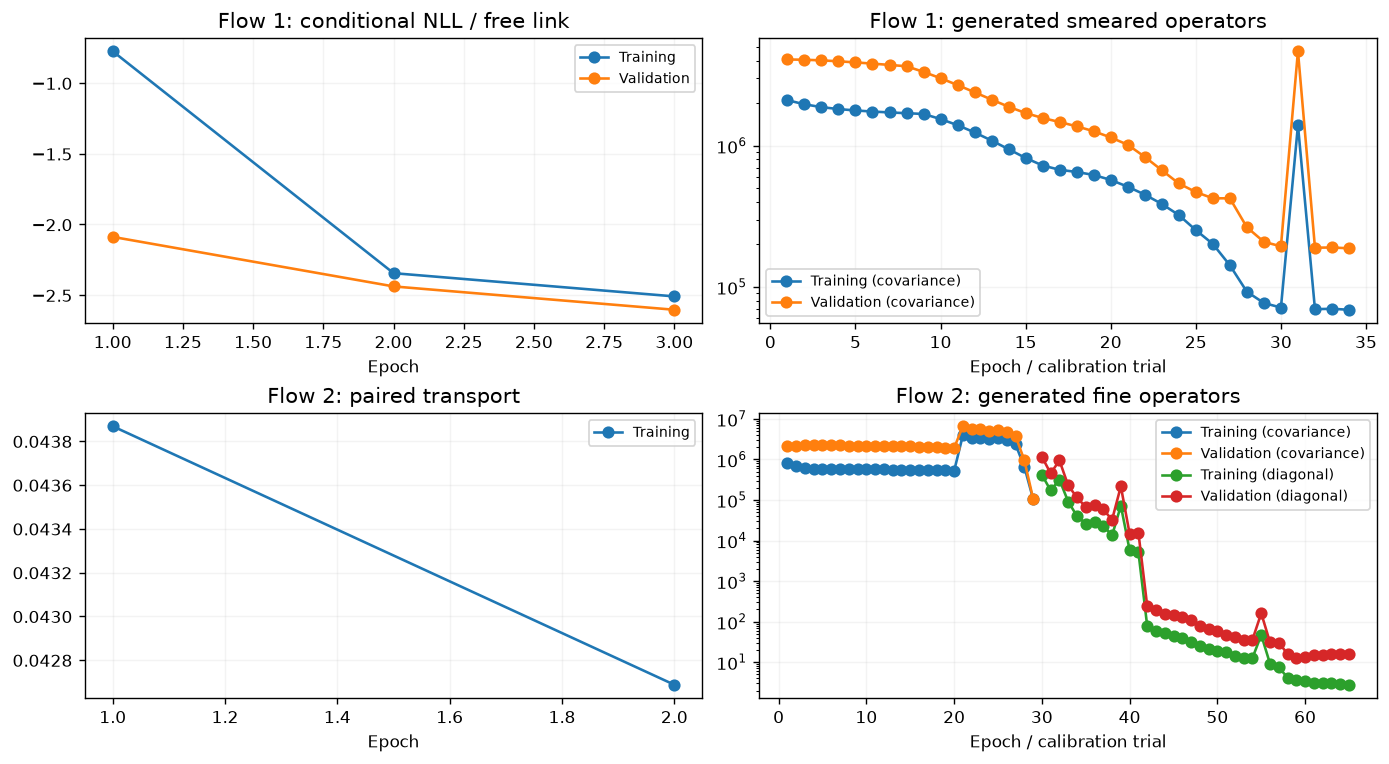

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)
phases = ['conditional_nll', 'smeared_moments', 'paired_transport', 'generated_moments']
titles = ['Flow 1: conditional NLL / free link', 'Flow 1: generated smeared operators', 'Flow 2: paired transport', 'Flow 2: generated fine operators']
for ax, phase, title in zip(axes.flat, phases, titles):
    rows = [r for r in history if r['phase'] == phase]
    moment = phase in ['smeared_moments', 'generated_moments']
    groups = sorted({r.get('mean_metric', 'covariance') for r in rows}) if moment else ['all']
    for metric in groups:
        current = [r for r in rows if not moment or r.get('mean_metric', 'covariance') == metric]
        suffix = f' ({metric})' if moment else ''
        ax.plot([r['epoch'] for r in current], [r['train_loss'] for r in current], 'o-', label='Training'+suffix)
        val = [r for r in current if 'validation_loss' in r]
        if val:
            ax.plot([r['epoch'] for r in val], [r['validation_loss'] for r in val], 'o-', label='Validation'+suffix)
    if phase in ['smeared_moments', 'generated_moments']:
        ax.set_yscale('log')
    ax.set(title=title, xlabel='Epoch / calibration trial' if moment else 'Epoch')
    ax.legend(fontsize=8)
plt.show()


## Final fine-lattice distributions

One fresh latent draw is used per held-out downsampled configuration.
The reference and generated samples are paired through their coarse source;
the combined-standard-error shift is shown as the same descriptive diagnostic
used for downsampling, not as an independent-sample hypothesis test.
Acceptance requires every mean within **one target standard deviation** and
every width ratio in **[0.8, 1.2]**. A shared set of bins is used for each panel.


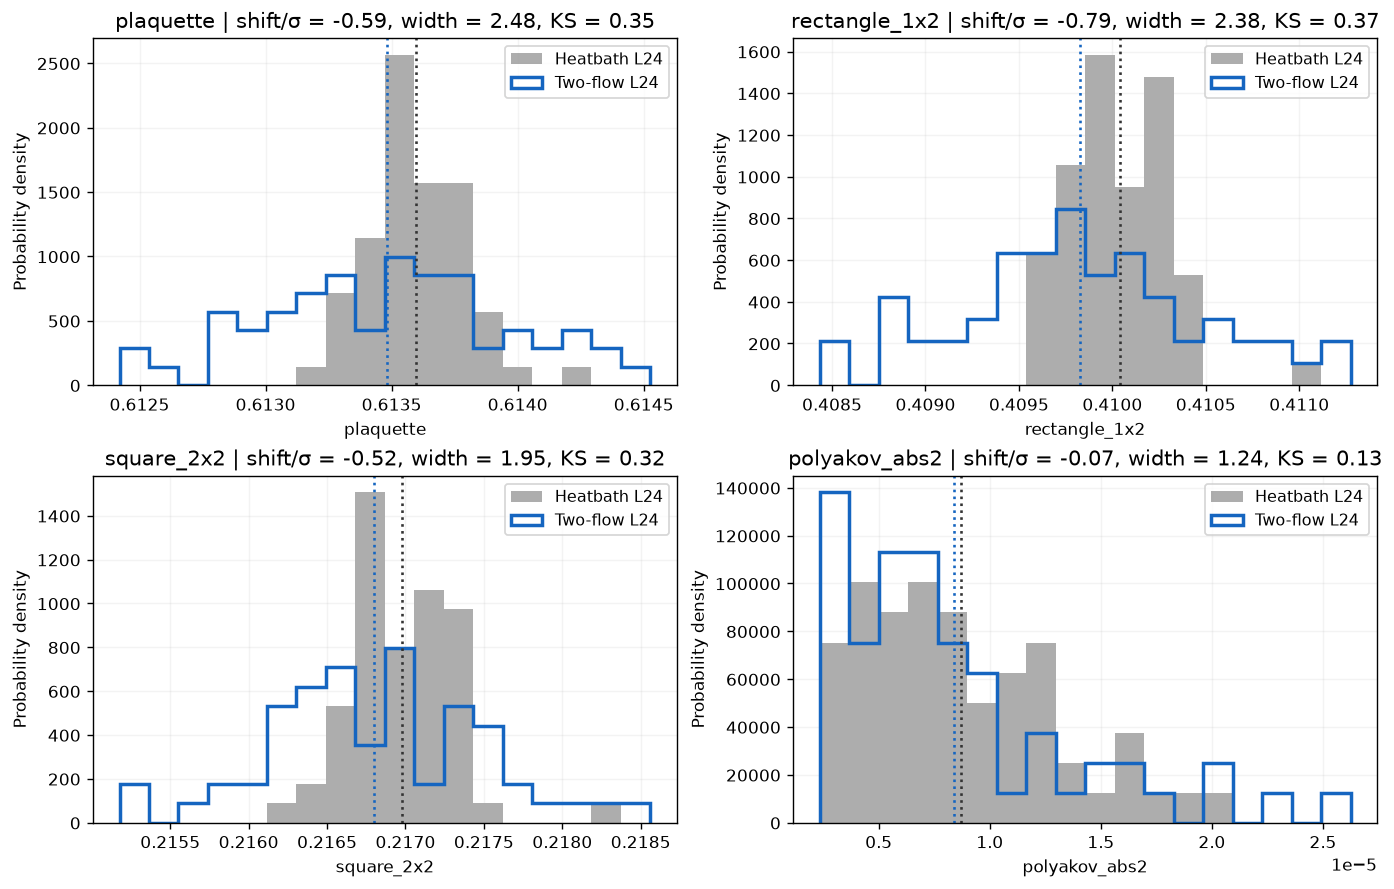

| Operator | Heatbath mean | Two-flow mean | Relative mean error | Shift / target σ | Width ratio | KS | Pass |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | :---: |
| plaquette | 0.6135947 | 0.6134816 | -0.018% | -0.590 | 2.479 | 0.350 | NO |
| rectangle_1x2 | 0.4100392 | 0.409827 | -0.052% | -0.789 | 2.382 | 0.367 | NO |
| square_2x2 | 0.2169795 | 0.2167982 | -0.084% | -0.520 | 1.946 | 0.317 | NO |
| polyakov_abs2 | 8.687498e-06 | 8.406797e-06 | -3.231% | -0.065 | 1.241 | 0.133 | NO |

**Final distribution criterion: FAIL.**

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for k, ax in enumerate(axes.flat):
    reference = data['fine_reference'][:, k]
    generated = data['flow2_fine'][:, k]
    bins = np.histogram_bin_edges(np.r_[reference, generated], bins=18)
    ax.hist(reference, bins=bins, density=True, alpha=.40, color='#333333', label='Heatbath L24')
    ax.hist(generated, bins=bins, density=True, histtype='step', linewidth=2, color='#1565c0', label='Two-flow L24')
    ax.axvline(reference.mean(), color='#333333', linestyle=':')
    ax.axvline(generated.mean(), color='#1565c0', linestyle=':')
    m = metrics['flow2_fine']
    ax.set(title=f"{names[k]} | shift/σ = {m['mean_shift_in_target_sigma'][k]:.2f}, width = {m['std_ratio'][k]:.2f}, KS = {m['ks_statistic'][k]:.2f}",
           xlabel=names[k], ylabel='Probability density')
    ax.ticklabel_format(axis='x', style='sci', scilimits=(-3, 3), useOffset=False)
    ax.legend(fontsize=9)
plt.show()
rows = ['| Operator | Heatbath mean | Two-flow mean | Relative mean error | Shift / target σ | Width ratio | KS | Pass |',
        '| --- | ---: | ---: | ---: | ---: | ---: | ---: | :---: |']
m = metrics['flow2_fine']
for k, name in enumerate(names):
    passed = abs(m['mean_shift_in_target_sigma'][k]) <= 1 and .8 <= m['std_ratio'][k] <= 1.2
    relative = 100*(m['mean'][k]/m['target_mean'][k]-1)
    rows.append(f"| {name} | {m['target_mean'][k]:.7g} | {m['mean'][k]:.7g} | {relative:+.3f}% | {m['mean_shift_in_target_sigma'][k]:.3f} | {m['std_ratio'][k]:.3f} | {m['ks_statistic'][k]:.3f} | {'YES' if passed else 'NO'} |")
display(Markdown('\n'.join(rows)))
display(Markdown(f"**Final distribution criterion: {'PASS' if m['acceptance']['distribution_match'] else 'FAIL'}.**"))


## Diagnose the two stages separately

The first row checks generated smeared fields against the actual smeared
heatbath fields. The second row applies Flow 2 to actual smeared test fields
(teacher input). This distinguishes errors introduced by Flow 1 from the
learned desmearing transport. Teacher input is a diagnostic, not the final
upsampling result.
Because Flow 2 is refined on generated Flow-1 fields, it can compensate for
Flow-1 bias: matching the final operators alone does not establish a faithful
inverse on actual smeared fields. Both input domains are therefore shown.


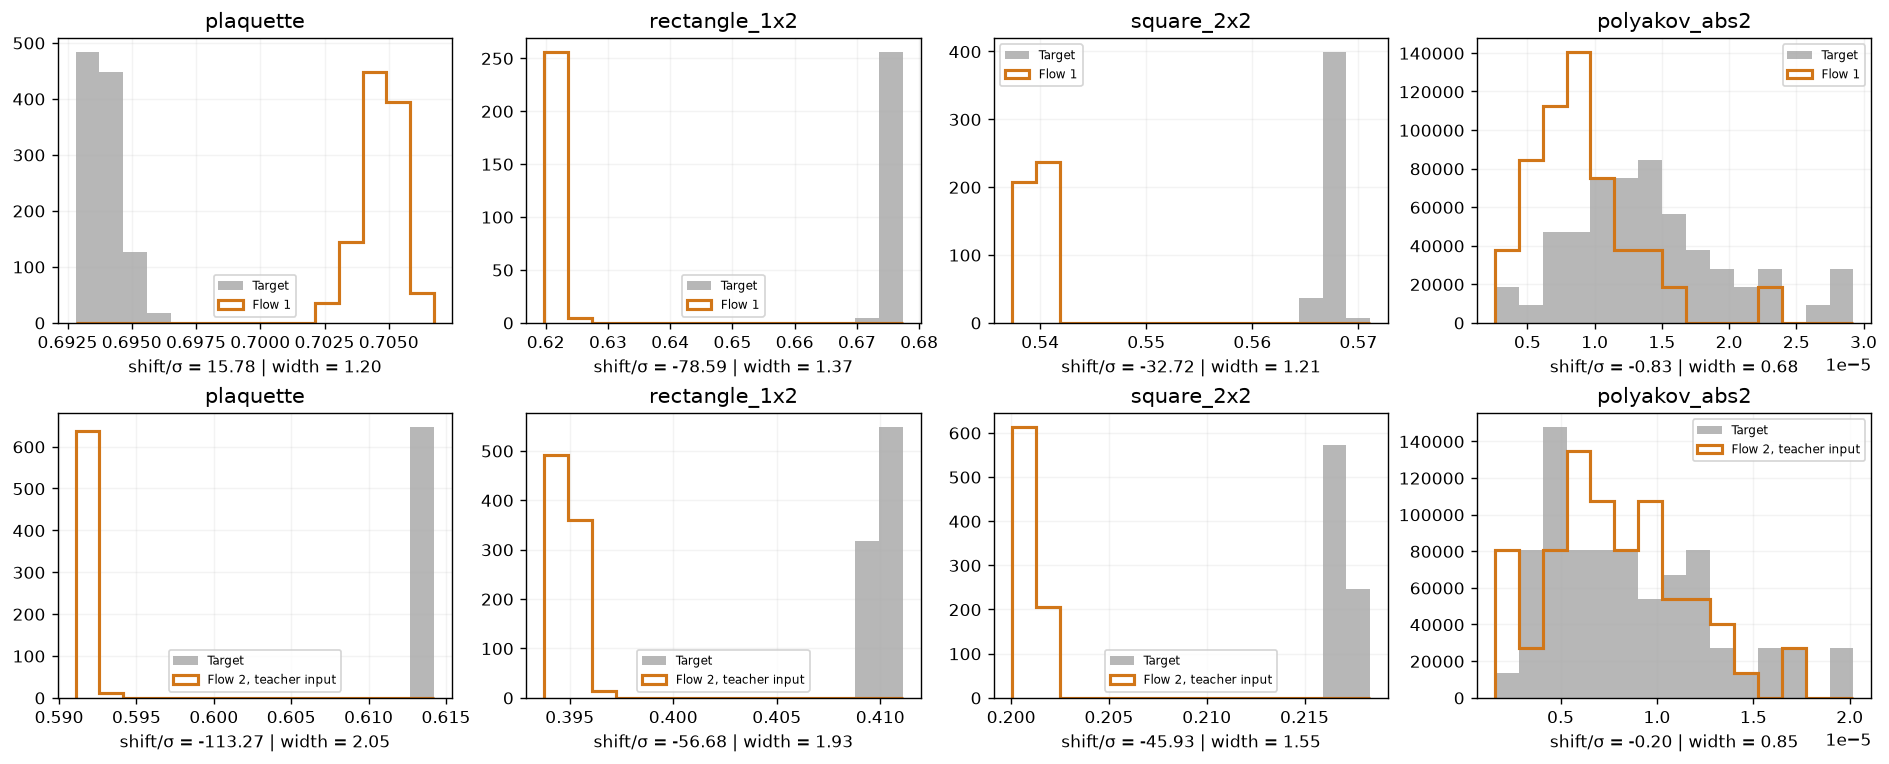

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6), constrained_layout=True)
for row, (candidate, target, label) in enumerate([
    ('flow1_smeared', 'smeared_reference', 'Flow 1'),
    ('teacher_fine', 'fine_reference', 'Flow 2, teacher input')]):
    for k in range(4):
        ax = axes[row, k]
        x, y = data[candidate][:, k], data[target][:, k]
        bins = np.histogram_bin_edges(np.r_[x, y], bins=15)
        ax.hist(y, bins=bins, density=True, alpha=.35, color='#333333', label='Target')
        ax.hist(x, bins=bins, density=True, histtype='step', linewidth=1.8, color='#d17618', label=label)
        ax.set(title=names[k], xlabel=f"shift/σ = {metrics[candidate]['mean_shift_in_target_sigma'][k]:.2f} | width = {metrics[candidate]['std_ratio'][k]:.2f}")
        ax.ticklabel_format(axis='x', style='sci', scilimits=(-3, 3), useOffset=False)
        ax.legend(fontsize=7)
plt.show()


## Numerical integrity and reproducibility

No heatbath/HMC sweeps are applied after either flow. The generated samples
are checked for SU(3) membership and Flow 1 is checked for its blocking
constraint. Independent PyQUDA measurements cross-check the Torch operators
when enabled during evaluation. Charts and numbers in this notebook can be
reproduced from the small result bundle committed beside it; training fields
remain under the ignored `artifacts/` directory.


In [5]:
print('Max SU(3) unitarity / determinant errors:', metrics['max_su3_errors'])
print('Max |block(Flow1) - coarse|:', metrics['max_blocking_error'])
differences = np.asarray(metrics['pyquda_differences'])
print('PyQUDA - Torch max |difference|:', np.abs(differences).max(axis=0) if differences.size else 'not run')
print('Acceptance:', metrics['flow2_fine']['acceptance'])
print('Frozen downsampling coefficients:', run['downsampling_architecture']['coefficients'])


Max SU(3) unitarity / determinant errors: [8.344650268554688e-06, 1.1026899301214144e-05]
Max |block(Flow1) - coarse|: 7.947573067212943e-06
PyQUDA - Torch max |difference|: [5.31990823e-08 6.37092319e-08 3.41511375e-08 1.52251038e-12]
Acceptance: {'distribution_match': False, 'test_all_means_within_one_standard_error': False, 'test_all_means_within_one_target_sigma': True, 'test_all_std_ratios_within_20_percent': False}
Frozen downsampling coefficients: [0.19842116820508549, -0.023623959150709608, -0.002876974930039361, -6.659929755087942e-05]


Training and report commands (repository root):

```bash
OMP_NUM_THREADS=2 OPENBLAS_NUM_THREADS=2 .venv/bin/python scripts/upsample/train.py --pyquda-check
.venv/bin/python scripts/upsample/calibrate.py --stage 1
.venv/bin/python scripts/upsample/calibrate.py --stage 2 --anneal-init
.venv/bin/python scripts/upsample/train.py --evaluate-only --pyquda-check
.venv/bin/python scripts/upsample/make_notebook.py
```

Set `RGFLOW_UPSAMPLE_RUN` to display another completed run. Checkpoint files
contain both flow state dictionaries and sweep counts. The current experiment
uses downsampled heatbath fields as its coarse source; transfer to an
independently generated L12 heatbath ensemble is a separate validation.
